MSE states that Polynomial Fit is the best method
RS states that Polynomial Fit is the best method
Slope: -0.3402171473058146, Intercept: 0.6815350421394135


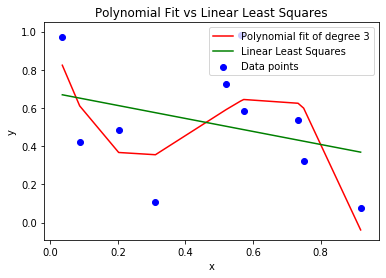

In [83]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
X = rng.random(10)
Y = rng.random(10)
X.sort()

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
lls_y=m*X+c

mse_lls = np.mean((Y - lls_y)**2)

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - lls_y)**2)
r_lls = 1 - (ss_res / ss_total)

degree = 3
Coefficients = np.polyfit(X, Y, degree)
polynomial = np.poly1d(Coefficients)
Y_pred = polynomial(X)

mse_pf = np.mean((Y - Y_pred)**2)

ss_res = np.sum((Y - Y_pred)**2)
r_pf = 1 - (ss_res / ss_total)

if mse_lls < mse_pf:
    print('MSE states that Least Linear Squares is the best method')
else:
    print('MSE states that Polynomial Fit is the best method')
    
if r_lls > r_pf:
    print('RS states that Least Linear Squares is the best method')
else:
    print('RS states that Polynomial Fit is the best method')

plt.scatter(X, Y, color='blue', label='Data points') 
plt.plot(X, Y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial Fit vs Linear Least Squares')
plt.xlabel('x')
plt.ylabel('y')

print(f"Slope: {m}, Intercept: {c}")
plt.plot(X, m*X +c, color='green', label=f'Linear Least Squares')
plt.legend()
plt.show()

In [119]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
x = np.linspace(0,10,10)
y = rng.random(10)

A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
lls_y=m*x+c

mse_lls = np.mean((y - lls_y)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - lls_y)**2)
r_lls = 1 - (ss_res / ss_total)
print('       Results for LLS:')
print('MSE: ',mse_lls,' RS: ',r_lls)

degree = 3
deg_max = len(x) + 1
degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

mse_pf = np.mean((y - y_pred)**2)
ss_res = np.sum((y - y_pred)**2)
r_cubic = 1 - (ss_res / ss_total)

print('')
print('       Results with degrees cranked up:')
for degree in range(3, deg_max + 1):
    coeff = np.polyfit(x, y, degree)
    poly = np.poly1d(coeff)
    y_pred1 = poly(x)
    mse_pf1 = np.mean((y - y_pred1)**2)

    ss_res1 = np.sum((y - y_pred1)**2)
    r_pf1 = 1 - (ss_res1 / ss_total)
    
    print('Degree: ',degree,' MSE: ',mse_pf1, ' RS: ',r_pf1)
    
    if(r_pf1 == 1):
        print('Degree ',degree,' is overfitting')
        break
        
print('')    
print('       Results with degrees cranked down:')
for degree in range(2, 0, -1):
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(x)
    mse_pf2 = np.mean((y - y_pred)**2)

    ss_res2 = np.sum((y - y_pred)**2)
    r_pf2 = 1 - (ss_res2 / ss_total)
    
    print('Degree: ',degree,' MSE: ',mse_pf2, ' RS: ',r_pf2)
    
    if(r_pf2 < 0.7 * r_cubic):
        print('Degree ', degree,' is underfitting')
        break

       Results for LLS:
MSE:  0.03685515554966704  RS:  0.557944387033702

       Results with degrees cranked up:
Degree:  3  MSE:  0.012001784273636393  RS:  0.8560457546672994
Degree:  4  MSE:  0.012001481290525765  RS:  0.8560493887690332
Degree:  5  MSE:  0.011498234595068043  RS:  0.862085532779714
Degree:  6  MSE:  0.010341548760654153  RS:  0.8759592895965098
Degree:  7  MSE:  0.0051379762251143515  RS:  0.9383730391114925
Degree:  8  MSE:  0.004738755719329057  RS:  0.9431614510110382
Degree:  9  MSE:  8.12022464423668e-21  RS:  1.0
Degree  9  is overfitting

       Results with degrees cranked down:
Degree:  2  MSE:  0.015513695960184306  RS:  0.8139224682470778
Degree:  1  MSE:  0.03685515554966704  RS:  0.557944387033702
Degree  1  is underfitting


In [112]:
import numpy as np

degree = 3
for degree in range(3, 0, -1):
    V = np.vander(X, N=degree+1, increasing=True)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, Y)
    
    a = np.linalg.solve(VT_V, VT_y)
    yv_pred = V@a
    
    mse_v = np.mean((Y - yv_pred)**2)
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - yv_pred)**2)
    r_v = 1 - (ss_res / ss_total)
    
    print('Degree: ',degree,' MSE: ',mse_v, ' RS: ',r_v)

Degree:  3  MSE:  0.03708289472086237  RS:  0.5810732507365439
Degree:  2  MSE:  0.07376827379332575  RS:  0.1666372495556926
Degree:  1  MSE:  0.07922328180917323  RS:  0.10501183459046237
